<a href="https://colab.research.google.com/github/jairaj023/Internship-Practice/blob/main/Day_10_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
from google.colab import files
upload = files.upload()

Saving raw_jobs.csv to raw_jobs.csv


In [4]:
df = pd.read_csv('raw_jobs.csv')

In [5]:
df["clean_description"] = (df["job_description"].fillna("").astype(str).str.lower().apply(lambda x: re.sub(r"[^a-zA-Z\s]", " ", x)).apply(lambda x: re.sub(r"\s+", " ", x).strip()))

df[["job_description", "clean_description"]].head()

,job_description,clean_description
0,We are looking for a Python Developer to join ...,we are looking for a python developer to join ...
1,We are looking for a Data Scientist to join ou...,we are looking for a data scientist to join ou...
2,We are looking for a Data Engineer to join our...,we are looking for a data engineer to join our...
3,We are looking for a Business Analyst to join ...,we are looking for a business analyst to join ...
4,We are looking for a Business Analyst to join ...,we are looking for a business analyst to join ...


In [6]:
vectorizer = TfidfVectorizer(ngram_range=(1, 3), stop_words="english", max_features=3000)

X = vectorizer.fit_transform(df["clean_description"])

print("N-Gram Matrix Shape:", X.shape)

N-Gram Matrix Shape: (10000, 2359)


In [7]:
ngrams = vectorizer.get_feature_names_out()

print("Total N-Grams:", len(ngrams))
print("\nFirst 50 N-Grams:\n")

for ngram in ngrams[:50]:
    print(ngram)

Total N-Grams: 2359

First 50 N-Grams:

accenture
accenture candidate
accenture candidate work
administrator
administrator join
administrator join team
adobe
adobe candidate
adobe candidate work
ai
ai engineer
ai engineer join
amazon
amazon candidate
amazon candidate work
analysis
analysis candidates
analysis candidates fresher
analysis candidates years
analysis communication
analysis communication candidates
analysis communication excel
analysis communication power
analysis communication sql
analysis excel
analysis excel candidates
analysis excel communication
analysis excel power
analysis excel sql
analysis power
analysis power bi
analysis sql
analysis sql candidates
analysis sql communication
analysis sql excel
analysis sql power
analyst
analyst join
analyst join team
analytics
analytics candidates
analytics candidates fresher
analytics candidates years
analytics excel
analytics excel candidates
analytics excel python
analytics excel sql
analytics excel testing
analytics python
anal

In [8]:
ngram_scores = X.mean(axis=0).A1

ngram_df = pd.DataFrame({"N-Gram": ngrams, "TF-IDF Score": ngram_scores})

ngram_df.head()

,N-Gram,TF-IDF Score
0,accenture,0.006929
1,accenture candidate,0.006929
2,accenture candidate work,0.006929
3,administrator,0.006971
4,administrator join,0.006971


In [9]:
top_ngrams = ngram_df.sort_values(by="TF-IDF Score", ascending=False)

top_ngrams.head(30)

,N-Gram,TF-IDF Score
2342,work,0.072259
817,include,0.072259
407,data,0.045823
1984,software,0.038111
266,business,0.038038
2310,testing,0.037464
2278,teams testing,0.036129
502,delivering high,0.036129
2277,teams,0.036129
503,delivering high quality,0.036129


In [10]:
print("Top 30 Important N-Grams:\n")

for _, row in top_ngrams.head(30).iterrows():
    print(
        f"{row['N-Gram']} : "
        f"{row['TF-IDF Score']:.4f}"
    )

Top 30 Important N-Grams:

work : 0.0723
include : 0.0723
data : 0.0458
software : 0.0381
business : 0.0380
testing : 0.0375
teams testing : 0.0361
delivering high : 0.0361
teams : 0.0361
delivering high quality : 0.0361
analyzing requirements : 0.0361
analyzing : 0.0361
data software business : 0.0361
analyzing requirements collaborating : 0.0361
testing applications : 0.0361
teams testing applications : 0.0361
testing applications documenting : 0.0361
data software : 0.0361
experience : 0.0361
applications documenting : 0.0361
solutions analyzing : 0.0361
applications : 0.0361
skills : 0.0361
skills include : 0.0361
applications documenting work : 0.0361
solutions : 0.0361
documenting work delivering : 0.0361
team : 0.0361
developing solutions : 0.0361
documenting work : 0.0361


In [11]:
unigrams = ngram_df[ngram_df["N-Gram"].str.split().str.len() == 1].sort_values("TF-IDF Score", ascending=False)

print("Top 20 Unigrams:\n")
print(unigrams.head(20))

Top 20 Unigrams:

                N-Gram  TF-IDF Score
817            include      0.072259
2342              work      0.072259
407               data      0.045823
1984          software      0.038111
266           business      0.038038
2310           testing      0.037464
572        documenting      0.036129
271          candidate      0.036129
274         candidates      0.036129
294      collaborating      0.036129
777               high      0.036129
501         delivering      0.036129
671         experience      0.036129
2236              team      0.036129
1938            skills      0.036129
1989         solutions      0.036129
1886  responsibilities      0.036129
1883      requirements      0.036129
1706          projects      0.036129
1844           quality      0.036129


In [12]:
bigrams = ngram_df[ngram_df["N-Gram"].str.split().str.len() == 2].sort_values("TF-IDF Score", ascending=False)

print("Top 20 Bigrams:\n")
print(bigrams.head(20))

Top 20 Bigrams:

                          N-Gram  TF-IDF Score
2278               teams testing      0.036129
113     applications documenting      0.036129
1887    responsibilities include      0.036129
1939              skills include      0.036129
1985           software business      0.036129
1990         solutions analyzing      0.036129
1881             required skills      0.036129
1845             quality results      0.036129
1884  requirements collaborating      0.036129
876           include developing      0.036129
1205                   join team      0.036129
272               candidate work      0.036129
269            business projects      0.036129
1707           projects required      0.036129
64        analyzing requirements      0.036129
778                 high quality      0.036129
2345             work delivering      0.036129
2343                   work data      0.036129
426                data software      0.036129
502              delivering high      0.036

In [13]:
trigrams = ngram_df[ngram_df["N-Gram"].str.split().str.len() == 3].sort_values("TF-IDF Score", ascending=False)

print("Top 20 Trigrams:\n")
print(trigrams.head(20))

Top 20 Trigrams:

                                    N-Gram  TF-IDF Score
2317      testing applications documenting      0.036129
65    analyzing requirements collaborating      0.036129
2279            teams testing applications      0.036129
1882               required skills include      0.036129
1888   responsibilities include developing      0.036129
1885      requirements collaborating teams      0.036129
114          applications documenting work      0.036129
877           include developing solutions      0.036129
270             business projects required      0.036129
1991      solutions analyzing requirements      0.036129
273                    candidate work data      0.036129
574            documenting work delivering      0.036129
427                 data software business      0.036129
2344                    work data software      0.036129
2346                  work delivering high      0.036129
296            collaborating teams testing      0.036129
1986         

In [14]:
multi_word = ngram_df[ngram_df["N-Gram"].str.split().str.len() >= 2].sort_values("TF-IDF Score", ascending=False)

print("Top Multi-Word Terms:\n")

for _, row in multi_word.head(30).iterrows():
    print(
        f"{row['N-Gram']} : "
        f"{row['TF-IDF Score']:.4f}"
    )

Top Multi-Word Terms:

work delivering : 0.0361
work data software : 0.0361
work data : 0.0361
collaborating teams testing : 0.0361
collaborating teams : 0.0361
software business : 0.0361
teams testing : 0.0361
skills include : 0.0361
responsibilities include : 0.0361
analyzing requirements : 0.0361
analyzing requirements collaborating : 0.0361
responsibilities include developing : 0.0361
data software : 0.0361
data software business : 0.0361
candidate work : 0.0361
candidate work data : 0.0361
business projects required : 0.0361
delivering high quality : 0.0361
applications documenting work : 0.0361
software business projects : 0.0361
developing solutions analyzing : 0.0361
developing solutions : 0.0361
applications documenting : 0.0361
solutions analyzing requirements : 0.0361
required skills include : 0.0361
teams testing applications : 0.0361
requirements collaborating : 0.0361
requirements collaborating teams : 0.0361
required skills : 0.0361
quality results : 0.0361


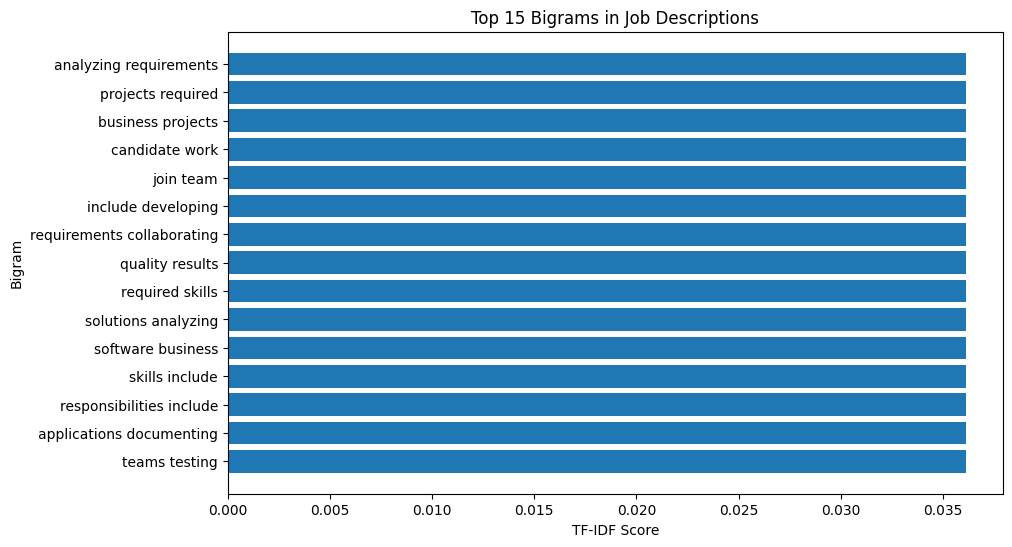

In [15]:
import matplotlib.pyplot as plt

top_bigrams = bigrams.head(15).sort_values("TF-IDF Score")

plt.figure(figsize=(10, 6))

plt.barh(top_bigrams["N-Gram"], top_bigrams["TF-IDF Score"])

plt.xlabel("TF-IDF Score")
plt.ylabel("Bigram")
plt.title("Top 15 Bigrams in Job Descriptions")

plt.show()

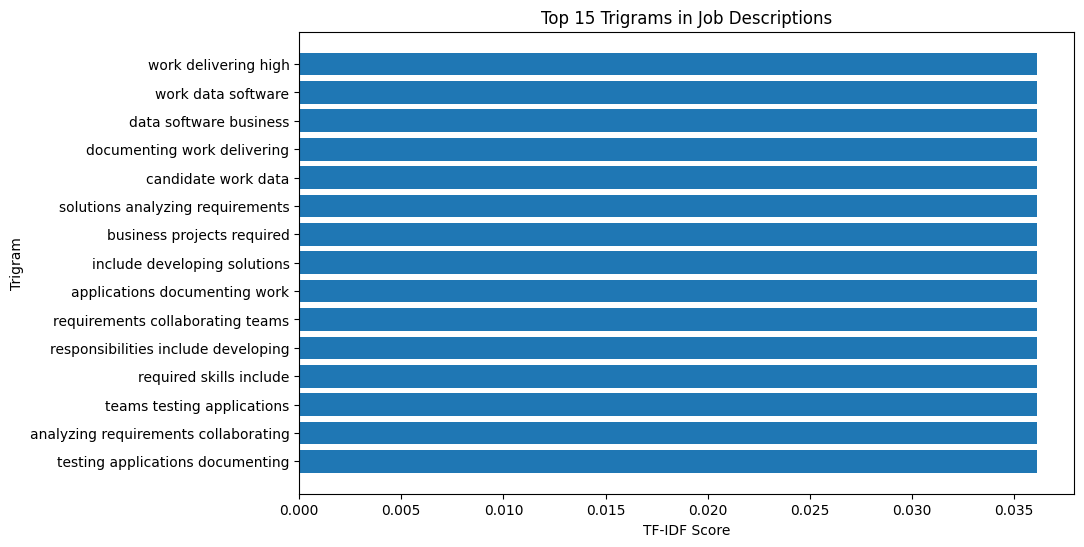

In [16]:
top_trigrams = trigrams.head(15).sort_values("TF-IDF Score")

plt.figure(figsize=(10, 6))

plt.barh(top_trigrams["N-Gram"], top_trigrams["TF-IDF Score"])

plt.xlabel("TF-IDF Score")
plt.ylabel("Trigram")
plt.title("Top 15 Trigrams in Job Descriptions")

plt.show()

In [17]:
skills_to_check = [
    "machine learning",
    "deep learning",
    "power bi",
    "data science",
    "data analysis",
    "natural language processing",
    "computer vision",
    "cloud computing"
]

for skill in skills_to_check:
    result = ngram_df[ngram_df["N-Gram"] == skill]

    if not result.empty:
        score = result["TF-IDF Score"].iloc[0]
        print(f"{skill} : {score:.4f}")
    else:
        print(f"{skill} : Not found")

machine learning : 0.0184
deep learning : 0.0062
power bi : 0.0185
data science : Not found
data analysis : 0.0061
natural language processing : Not found
computer vision : Not found
cloud computing : 0.0053


In [18]:
ngram_df.to_csv("Ngram_Analysis.csv", index=False)

bigrams.to_csv("Top_Bigrams.csv", index=False)

trigrams.to_csv("Top_Trigrams.csv", index=False)

print("N-Gram analysis files saved successfully!")

N-Gram analysis files saved successfully!
